# **CA3 - Reinforcement Learning**

In [ ]:
# !pip install -i https://mirror-pypi.runflare.com/simple "gym==0.26.2" "numpy<2" pygame matplotlib

In [16]:
import gym
import math
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

### **PART 1: AGENT IMPLEMENTATION**

In [17]:
if not hasattr(np, "bool8"):
    np.bool8 = np.bool_

/tmp/ipykernel_133173/920200510.py:1: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not hasattr(np, "bool8"):


In [18]:
class QLearningAgent:
    def __init__(
        self,
        env,
        buckets=(40, 40),
        alpha=0.05,
        gamma=0.99,
        epsilon_strategy='exponential',
        episodes=100000,
        seed=400
    ):
        self.env = env
        self.buckets = buckets
        self.alpha = alpha
        self.gamma = gamma
        self.episodes = episodes
        self.epsilon_strategy = epsilon_strategy
        self.seed = seed

        self.rng = np.random.default_rng(seed)
        self.env.action_space.seed(seed)

        self.lower_bounds = self.env.observation_space.low
        self.upper_bounds = self.env.observation_space.high

        self.Q_table = np.zeros(self.buckets + (self.env.action_space.n,))
        self.visit_count = np.zeros(self.buckets)       # Added this to know each state has been seen how many times. Q of low count states are not reliable

        self.threshold = self.env.spec.reward_threshold
        print('threshold:', self.threshold)

    def reset_env(self, episode=0):
        reset_result = self.env.reset(seed=self.seed + episode)

        if isinstance(reset_result, tuple):
            obs = reset_result[0]
        else:
            obs = reset_result

        return obs

    def discretize_state(self, obs):
        """
        Convert continuous observation to a discrete state.
        """
        ratios = (obs - self.lower_bounds) / (self.upper_bounds - self.lower_bounds)        
        indices = np.floor(ratios * np.array(self.buckets)).astype(int)        
        indices = np.clip(indices, 0, np.array(self.buckets) - 1)       # Keep the values in [0, bucket_size - 1]
        
        return tuple(indices)

    def choose_action(self, state, epsilon):
        """
        Select an action using epsilon-greedy policy.
        """
        if self.rng.random() < epsilon:
            return int(self.rng.choice(self.env.action_space.n))
        return int(np.argmax(self.Q_table[state]))

    def get_epsilon(self, episode):
        """
        Return epsilon for current episode.
        """
        EPSILON_MAX = 1.0
        EPSILON_MIN = 0.01

        if self.epsilon_strategy == "constant":
            return EPSILON_MIN * 10
        
        if self.epsilon_strategy == "linear":
            return max(EPSILON_MIN, 
                       EPSILON_MAX - (episode / self.episodes))
        
        if self.epsilon_strategy == "logarithmic":
            return max(EPSILON_MIN,
                       min(EPSILON_MAX, 
                           EPSILON_MAX / np.log10(episode + 2)))     # +2 so the arguement is not zero and the result is not 0 (log(1) = 0)

        if self.epsilon_strategy == "exponential":
            return max(EPSILON_MIN, 
                       EPSILON_MAX * np.exp(-5 * episode / self.episodes))
        
        return EPSILON_MIN * 10

    def train(self):
        """
        Train the Q-learning agent.
        Q(s,a) <- Q(s,a) + alpha * [r + gamma * max_a' Q(s',a') - Q(s,a)]
        """
        scores_window = deque(maxlen=100)

        scores_array = []
        avg_scores_array = []
        epsilons_array = []
        shaped_scores_array = []

        for episode in range(self.episodes):
            # Reset environment
            obs = self.reset_env(episode)
            state = self.discretize_state(obs)

            # Compute epsilon
            epsilon = self.get_epsilon(episode)

            done =  False
            total_reward = 0.0

            while not done:
                self.visit_count[state] += 1

                # Choose action using epsilon-greedy policy
                action = self.choose_action(state, epsilon)

                step_result = self.env.step(action)

                if len(step_result) == 4:
                    next_obs, reward, done, _ = step_result
                else:
                    next_obs, reward, terminated, truncated, _ = step_result
                    done = terminated or truncated

                next_state = self.discretize_state(next_obs)

                # Update Q-table 
                best_next_q = np.max(self.Q_table[next_state])
                td_target = reward + self.gamma * best_next_q
                td_error = td_target - self.Q_table[state + (action,)]
                self.Q_table[state + (action,)] += self.alpha * td_error

                total_reward += reward
                state = next_state

            scores_window.append(total_reward)
            scores_array.append(total_reward)
            avg_score = np.mean(scores_window)
            avg_scores_array.append(avg_score)
            epsilons_array.append(epsilon)
            shaped_scores_array.append(total_reward)

            # Log episode reward
            if (episode + 1) % 5000 == 0:
                print(f"Episode {episode + 1}/{self.episodes} | Average Reward: {avg_scores_array[-1]:.2f} | Epsilon: {epsilon:.4f}")

            # Check stopping condition
            if self.threshold is not None and len(scores_window) == 100 and avg_score >= self.threshold:
                print(f"It took only {episode + 1} episodes for the car to solve the Environment! Average Score: {avg_score:.2f}")
                break
        
        return scores_array, avg_scores_array, epsilons_array, shaped_scores_array

    def evaluate(self, episodes=100):
        """
        Evaluate the trained agent without exploration (epsilon=0).
        Always picks the greedy action (argmax Q).
        """
        eval_scores = []

        for episode in range(episodes):
            obs = self.reset_env(self.episodes + episode)
            state = self.discretize_state(obs)

            done = False
            total_reward = 0.0

            while not done:
                # Always picks the Greedy option
                action = int(np.argmax(self.Q_table[state]))

                step_result = self.env.step(action)

                if len(step_result) == 4:
                    next_obs, reward, done, _ = step_result
                else:
                    next_obs, reward, terminated, truncated, _ = step_result
                    done = terminated or truncated

                state = self.discretize_state(next_obs)
                total_reward += reward

            eval_scores.append(total_reward)

        return eval_scores

In [19]:
env = gym.make('MountainCar-v0')

visual_agent = QLearningAgent(
    env, 
    buckets=(40, 40), 
    epsilon_strategy='exponential', 
    episodes=500000,
    seed=400)

threshold: -110.0


In [20]:
def watch_agent(agent, episodes=5):
    env = gym.make("MountainCar-v0", render_mode="human")

    for episode in range(episodes):
        reset_result = env.reset(seed=agent.seed + 200000 + episode)

        if isinstance(reset_result, tuple):
            obs = reset_result[0]
        else:
            obs = reset_result

        state = agent.discretize_state(obs)
        done = False
        total_reward = 0

        while not done:
            action = np.argmax(agent.Q_table[state])

            step_result = env.step(action)

            if len(step_result) == 4:
                next_obs, reward, done, _ = step_result
            else:
                next_obs, reward, terminated, truncated, _ = step_result
                done = terminated or truncated

            state = agent.discretize_state(next_obs)
            total_reward += reward

        print(f"Episode {episode + 1} reward: {total_reward}")

    env.close()

In [21]:
watch_agent(visual_agent, episodes=5)

Episode 1 reward: -200.0
Episode 2 reward: -200.0
Episode 3 reward: -200.0
Episode 4 reward: -200.0
Episode 5 reward: -200.0


### **PART 2: AGENT TRAINING**

In [22]:
scores, avg_scores, epsilons, shaped_scores = visual_agent.train()

Episode 5000/500000 | Average Reward: -200.00 | Epsilon: 0.9512
Episode 10000/500000 | Average Reward: -200.00 | Epsilon: 0.9048
Episode 15000/500000 | Average Reward: -200.00 | Epsilon: 0.8607
Episode 20000/500000 | Average Reward: -200.00 | Epsilon: 0.8187
Episode 25000/500000 | Average Reward: -200.00 | Epsilon: 0.7788
Episode 30000/500000 | Average Reward: -200.00 | Epsilon: 0.7408
Episode 35000/500000 | Average Reward: -200.00 | Epsilon: 0.7047
Episode 40000/500000 | Average Reward: -200.00 | Epsilon: 0.6703
Episode 45000/500000 | Average Reward: -200.00 | Epsilon: 0.6376
Episode 50000/500000 | Average Reward: -199.68 | Epsilon: 0.6065
Episode 55000/500000 | Average Reward: -199.35 | Epsilon: 0.5770
Episode 60000/500000 | Average Reward: -197.02 | Epsilon: 0.5488
Episode 65000/500000 | Average Reward: -196.21 | Epsilon: 0.5221
Episode 70000/500000 | Average Reward: -194.59 | Epsilon: 0.4966
Episode 75000/500000 | Average Reward: -187.31 | Epsilon: 0.4724
Episode 80000/500000 | Ave

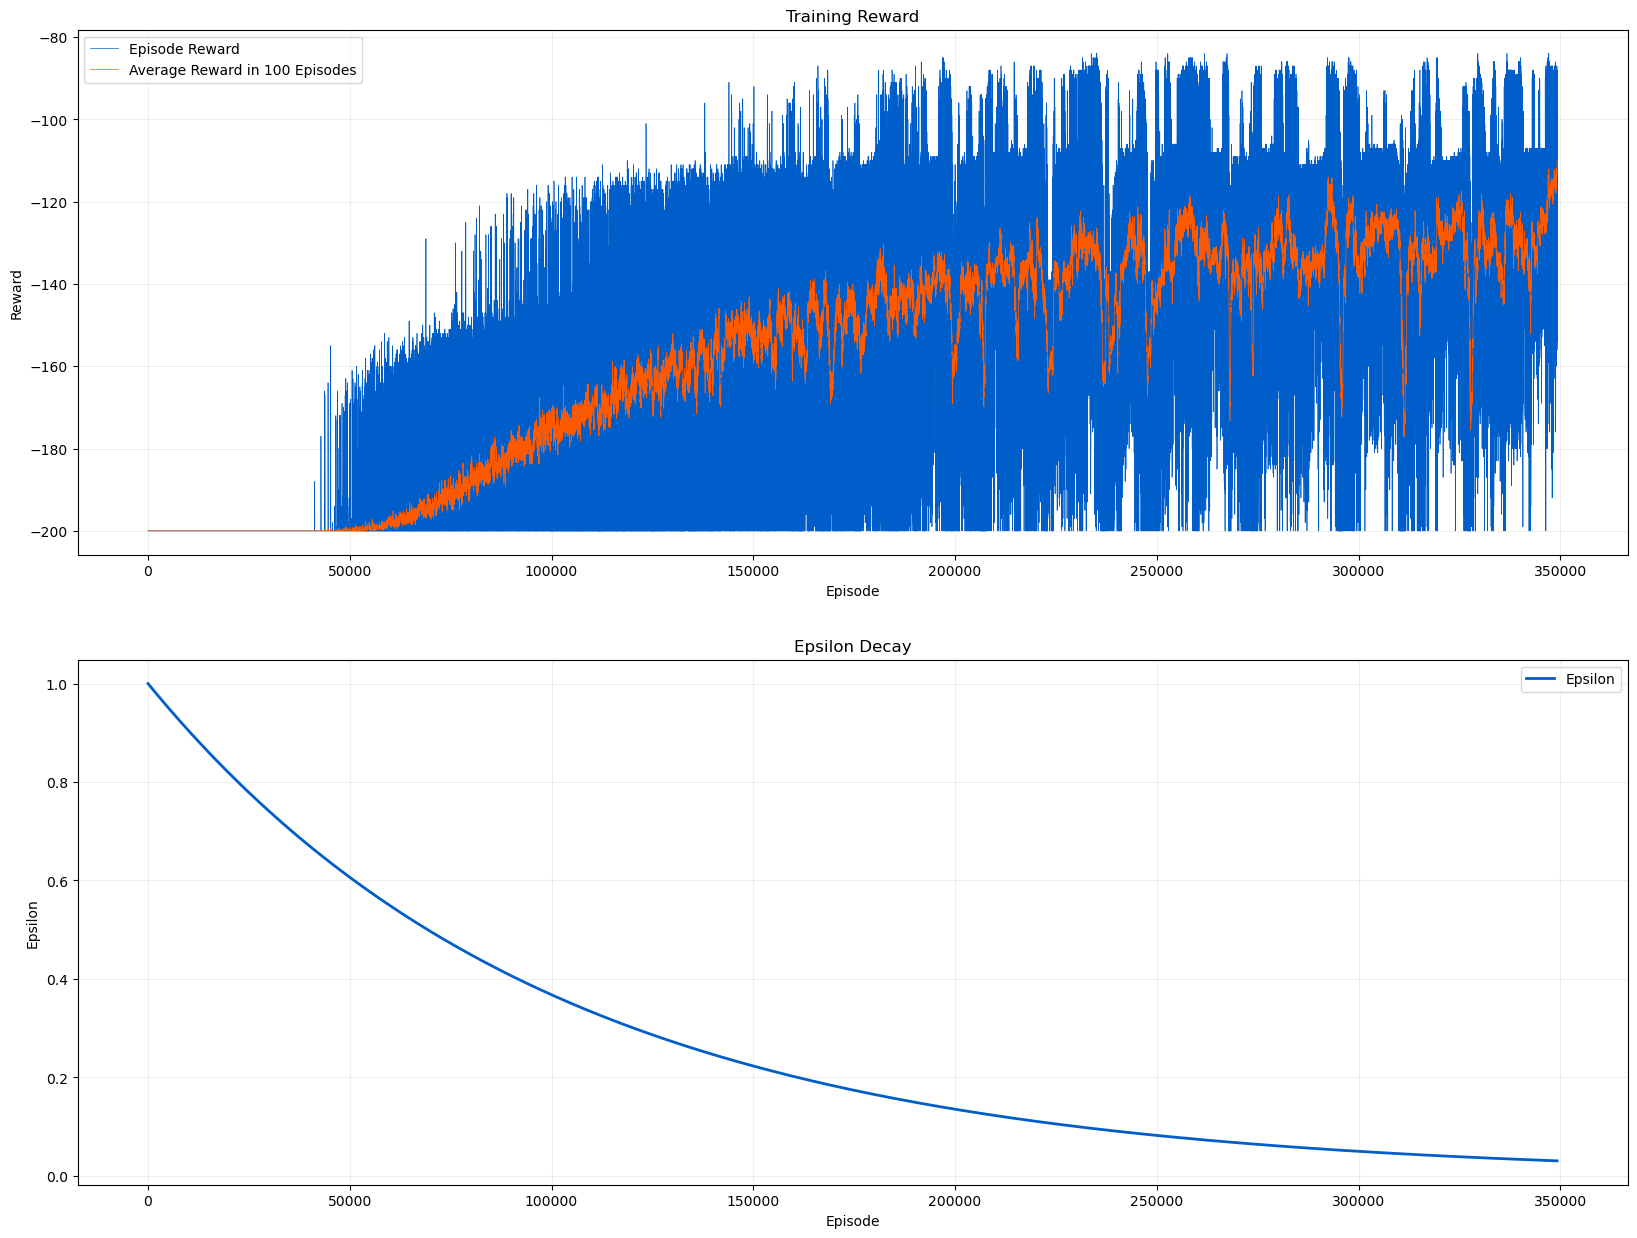

In [23]:
figure, axes = plt.subplots(2, 1, figsize=(20, 15))

axes[0].plot(scores, color="#005ECA", linewidth=0.5, label="Episode Reward")
axes[0].plot(avg_scores, color="#FF5900", linewidth=0.5, label="Average Reward in 100 Episodes")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Reward")
axes[0].set_title("Training Reward")
axes[0].legend()
axes[0].grid(True, alpha=0.2)

axes[1].plot(epsilons, color="#005ECA", linewidth=2, label="Epsilon")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Epsilon")
axes[1].set_title("Epsilon Decay")
axes[1].legend()
axes[1].grid(True, alpha=0.2)

plt.show()

### **PART 3: AGENT EVALUATION**

In [24]:
eval_scores = visual_agent.evaluate(episodes=100)

print("Evaluation without exploration")
print("Mean evaluation score:", np.mean(eval_scores))
print("Best evaluation score:", np.max(eval_scores))
print("Worst evaluation score:", np.min(eval_scores))

Evaluation without exploration
Mean evaluation score: -110.43
Best evaluation score: -87.0
Worst evaluation score: -153.0


In [25]:
watch_agent(visual_agent, episodes=5)

Episode 1 reward: -107.0
Episode 2 reward: -109.0
Episode 3 reward: -89.0
Episode 4 reward: -110.0
Episode 5 reward: -109.0


### **PART 4: EPSILON STRATEGY AND DISCRETIZATION GRANUALITY EXPERIMENTS**

In [30]:
def plot_training_result(scores, avg_scores, epsilons, title):
    """
    Plot training performance of the agent.

    1. Plot episode rewards.
    2. Plot moving average reward over the last 100 episodes.
    3. Plot epsilon values over episodes.
    """
    figure, axes = plt.subplots(2, 1, figsize=(20, 15))
    axes[0].plot(scores, color="#0087C1", linewidth=0.5, label="Epsiode Reward")
    axes[0].plot(avg_scores, color="#FF1AFF", linewidth=0.5, label="Average Reward in 100 Episodes")
    axes[0].axhline(y=-110, color="red", linestyle="--", label="Threshold")
    axes[0].set_xlabel("Episode")
    axes[0].set_ylabel("Reward")
    axes[0].set_title(f"{title} Episode Rewards")
    axes[0].legend()
    axes[0].grid(True, alpha=0.2)

    axes[1].plot(epsilons, color="#0087C1", linewidth=2, label="Epsilon")
    axes[1].set_xlabel("Episode")
    axes[1].set_ylabel("Epsilon")
    axes[1].set_title(f"{title} Epsilon Decay")
    axes[1].legend()
    axes[1].grid(True, alpha=0.2)

    plt.show()

def run_epsilon_experiments(episodes=100000, buckets=(40, 40), seed=400):
    """
    Run experiments comparing different epsilon strategies.

    1. Train agents using different epsilon strategies.
    2. Store training results.
    3. Evaluate the trained agents.
    4. Plot training results for each strategy.
    5. Plot comparison charts between strategies.
    """
    strategies = ['constant', 'linear', 'logarithmic', 'exponential']
    results = {}

    print("--- Running Epsilon Strategy Experiments ---")

    for strategy in strategies:
        print(f"Training using {strategy} Strategy")
        env = gym.make('MountainCar-v0')
        agent = QLearningAgent(
            env,
            buckets=buckets,
            epsilon_strategy=strategy,
            episodes=episodes,
            seed=seed
        )
        
        scores, avg_scores, epsilons, shaped_scores = agent.train()
        eval_scores = agent.evaluate()
        env.close()

        results[strategy] = {
            "scores": scores,
            "avg_scores": avg_scores,
            "epsilons": epsilons,
            "eval_scores": eval_scores
        }

        print("===================================")
        print("Mean evaluation score:", np.mean(eval_scores))
        print("Best evaluation score:", np.max(eval_scores))
        print("Worst evaluation score:", np.min(eval_scores))
        print("===================================")

        plot_training_result(scores, avg_scores, epsilons, f"Strategy: {strategy}")

    figure, axes = plt.subplots(2, 1, figsize=(20, 15))
    colors = ["#D11FCB", "#000DCA", "#179A00", "#940000"]
    for i, strategy in enumerate(strategies):
        axes[0].plot(results[strategy]["avg_scores"], color=colors[i], linewidth=2, alpha=0.8, label=strategy)
        axes[1].plot(results[strategy]["epsilons"], color=colors[i], linewidth=2, alpha=0.8, label=strategy)

    axes[0].axhline(y=-110, color="#000000", linestyle="--", label="Threshold")
    axes[0].set_xlabel("Episodes")
    axes[0].set_ylabel("Reward")
    axes[0].set_title("Comparison of Epsilon Strategies in Average Reward")
    axes[0].legend()
    axes[0].grid(True, alpha=0.2)

    axes[1].set_xlabel("Episodes")
    axes[1].set_ylabel("Epsilon")
    axes[1].set_title("Comparison of Epsilon Strategies in Epsilon Value")
    axes[1].legend()
    axes[1].grid(True, alpha=0.2)

    plt.show()

    return results


def run_bucket_experiments(episodes=100000, seed=400):
    """
    Run experiments with different discretization bucket sizes.

    TODO:
    1. Train agents with different discretization grids.
    2. Compare their training performance.
    3. Plot the results.
    """

    grids = [(5, 5), (100, 100)]
    results = {}

    print("\n--- Running Discretization Bucket Experiments ---")

    # TODO: iterate over discretization grids
    for grid in grids:
        pass

    # TODO: plot comparison of average rewards for different grids

    return results

--- Running Epsilon Strategy Experiments ---
Training using constant Strategy
threshold: -110.0
Episode 5000/100000 | Average Reward: -199.60 | Epsilon: 0.1000
Episode 10000/100000 | Average Reward: -188.60 | Epsilon: 0.1000
Episode 15000/100000 | Average Reward: -179.10 | Epsilon: 0.1000
Episode 20000/100000 | Average Reward: -157.09 | Epsilon: 0.1000
Episode 25000/100000 | Average Reward: -161.22 | Epsilon: 0.1000
Episode 30000/100000 | Average Reward: -143.07 | Epsilon: 0.1000
Episode 35000/100000 | Average Reward: -146.12 | Epsilon: 0.1000
Episode 40000/100000 | Average Reward: -157.37 | Epsilon: 0.1000
Episode 45000/100000 | Average Reward: -139.12 | Epsilon: 0.1000
Episode 50000/100000 | Average Reward: -144.82 | Epsilon: 0.1000
Episode 55000/100000 | Average Reward: -145.58 | Epsilon: 0.1000
Episode 60000/100000 | Average Reward: -138.21 | Epsilon: 0.1000
Episode 65000/100000 | Average Reward: -133.84 | Epsilon: 0.1000
Episode 70000/100000 | Average Reward: -149.35 | Epsilon: 0.

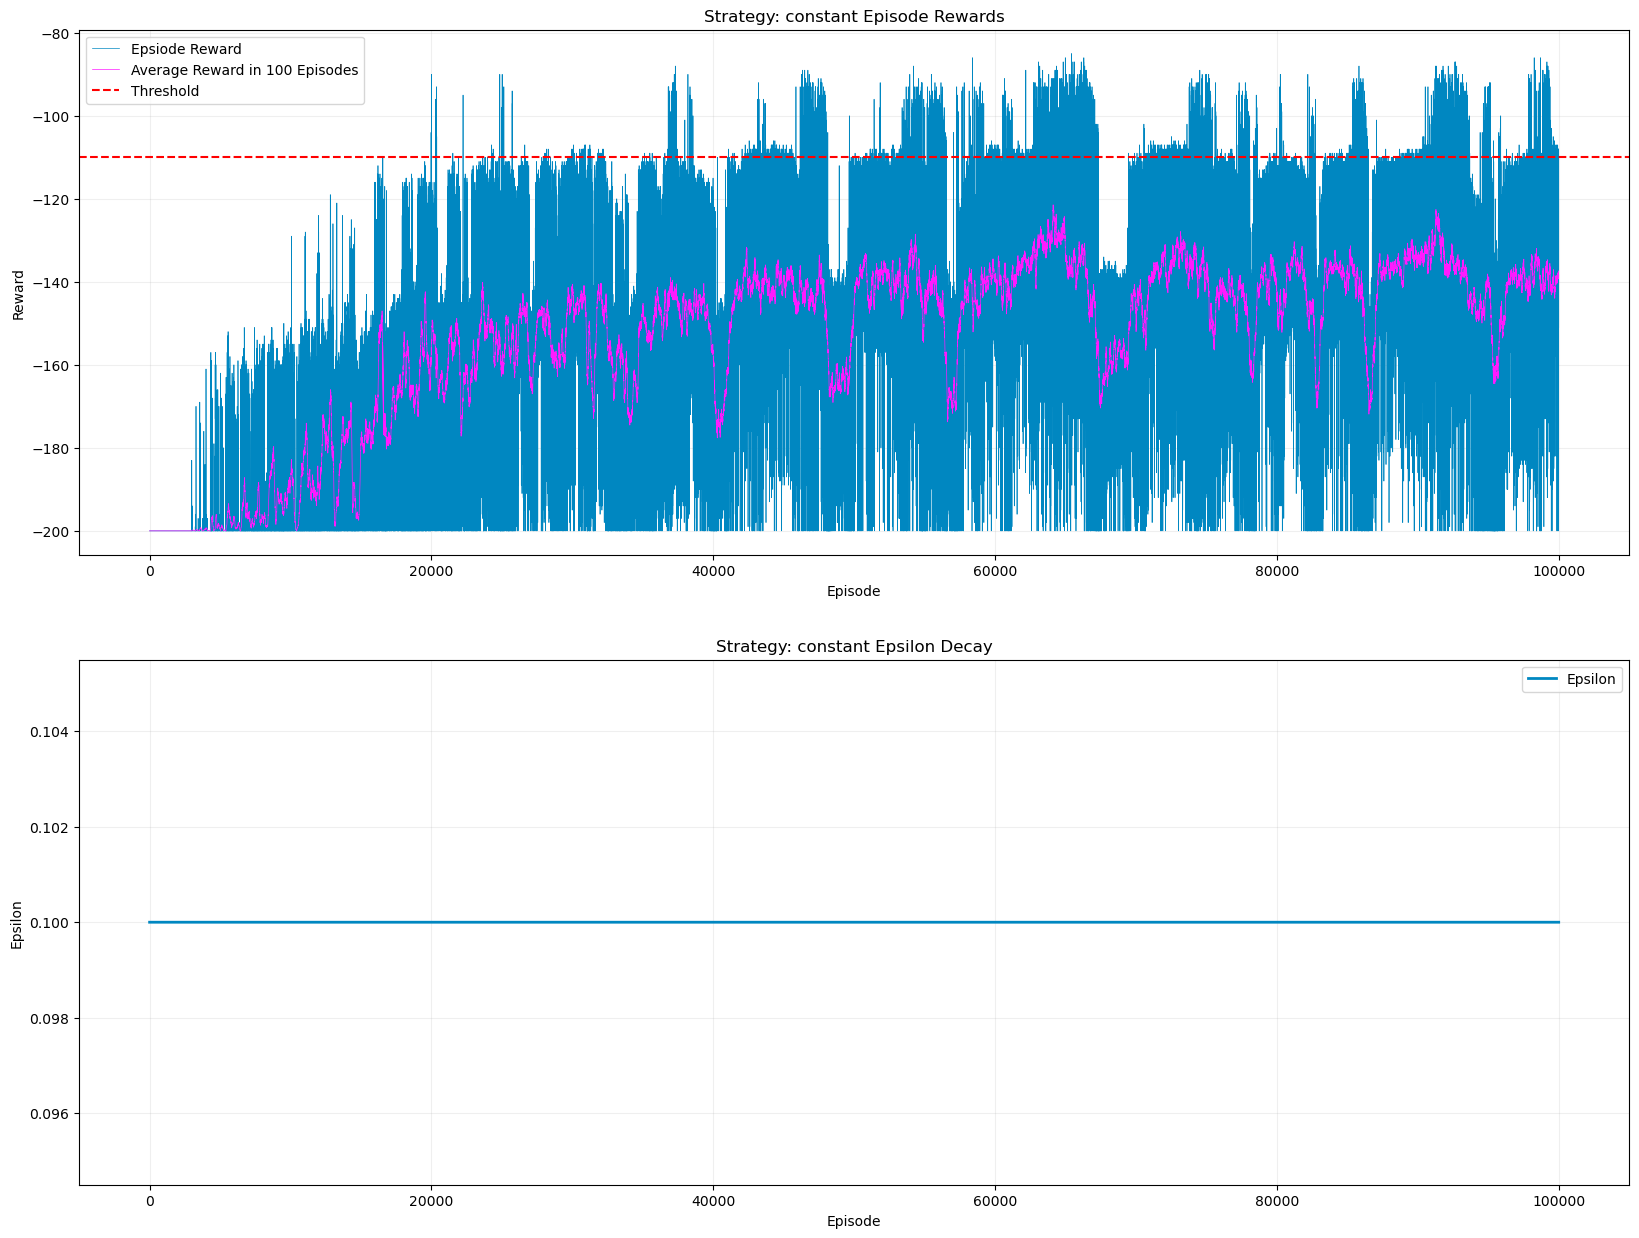

Training using linear Strategy
threshold: -110.0
Episode 5000/100000 | Average Reward: -200.00 | Epsilon: 0.9500
Episode 10000/100000 | Average Reward: -200.00 | Epsilon: 0.9000
Episode 15000/100000 | Average Reward: -200.00 | Epsilon: 0.8500
Episode 20000/100000 | Average Reward: -200.00 | Epsilon: 0.8000
Episode 25000/100000 | Average Reward: -200.00 | Epsilon: 0.7500
Episode 30000/100000 | Average Reward: -200.00 | Epsilon: 0.7000
Episode 35000/100000 | Average Reward: -200.00 | Epsilon: 0.6500
Episode 40000/100000 | Average Reward: -199.61 | Epsilon: 0.6000
Episode 45000/100000 | Average Reward: -198.65 | Epsilon: 0.5500
Episode 50000/100000 | Average Reward: -195.01 | Epsilon: 0.5000
Episode 55000/100000 | Average Reward: -189.97 | Epsilon: 0.4500
Episode 60000/100000 | Average Reward: -184.33 | Epsilon: 0.4000
Episode 65000/100000 | Average Reward: -173.74 | Epsilon: 0.3500
Episode 70000/100000 | Average Reward: -172.58 | Epsilon: 0.3000
Episode 75000/100000 | Average Reward: -16

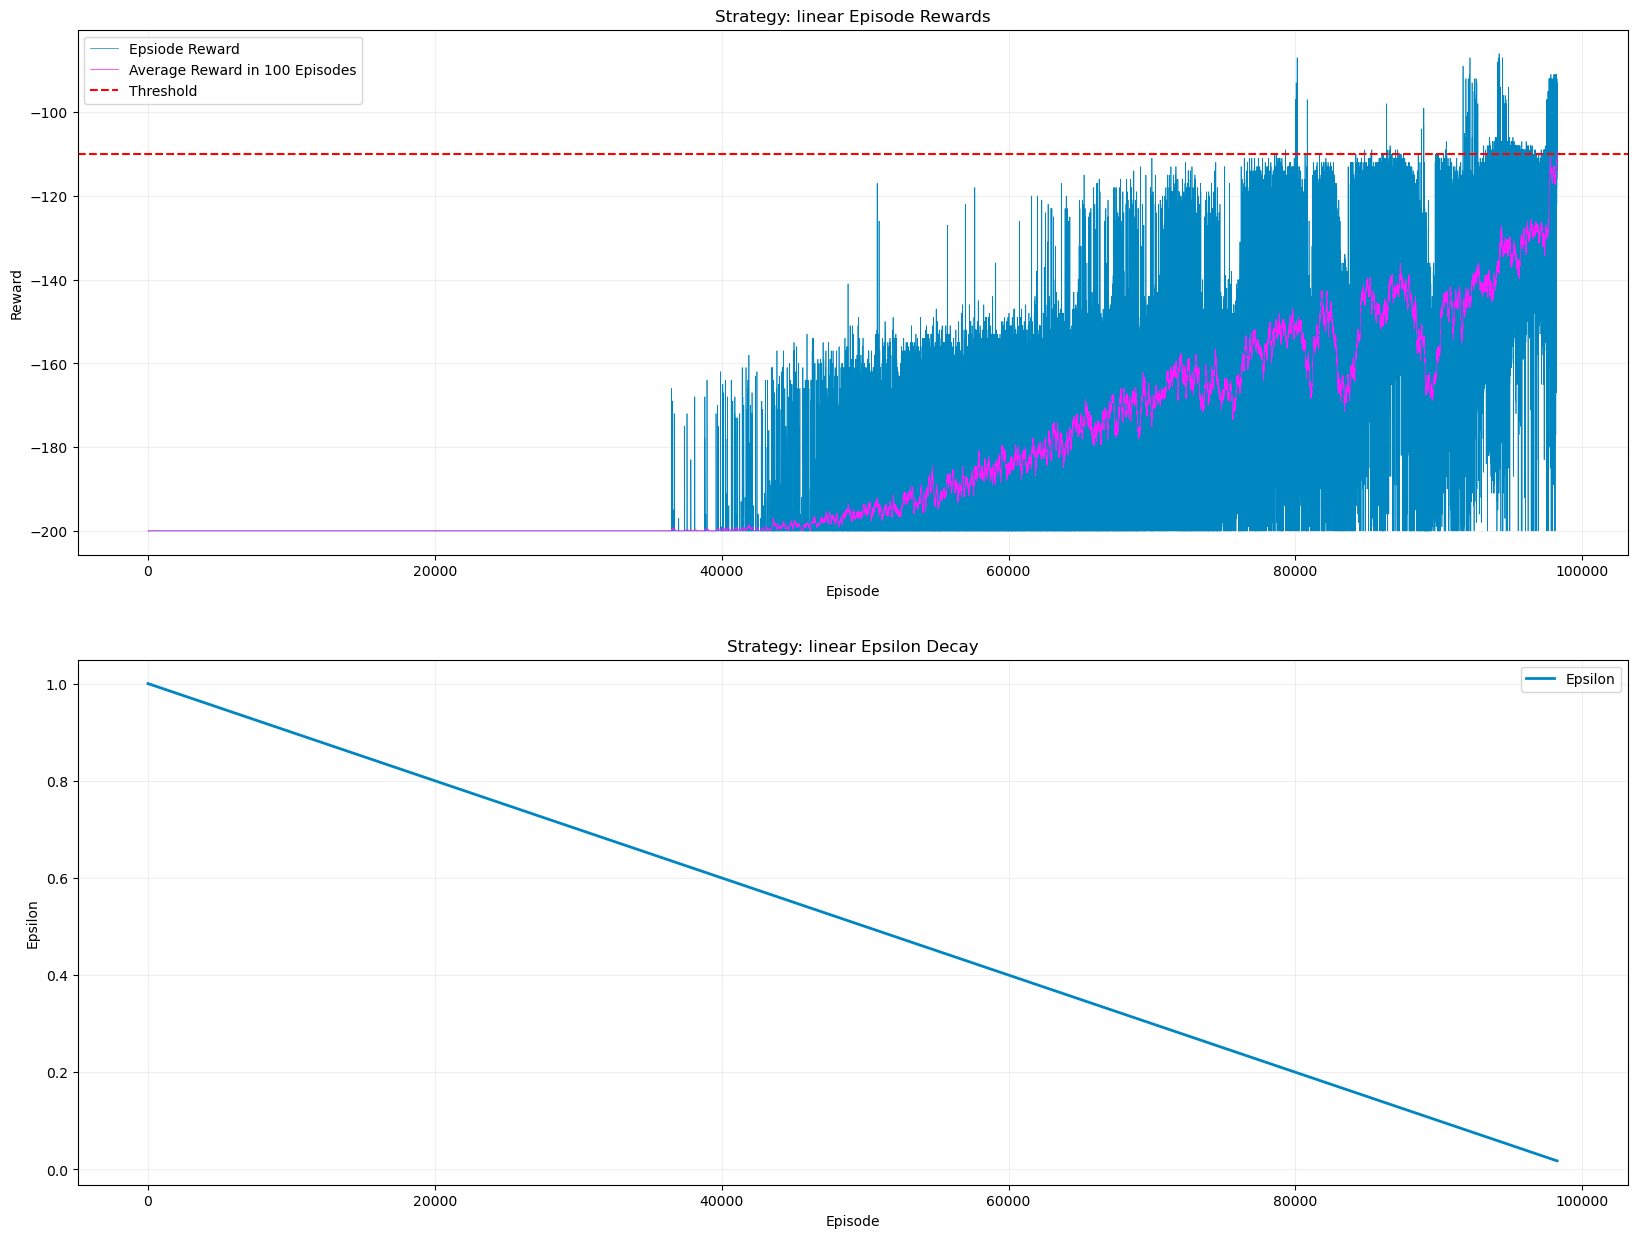

Training using logarithmic Strategy
threshold: -110.0
Episode 5000/100000 | Average Reward: -199.92 | Epsilon: 0.2703
Episode 10000/100000 | Average Reward: -193.80 | Epsilon: 0.2500
Episode 15000/100000 | Average Reward: -173.53 | Epsilon: 0.2395
Episode 20000/100000 | Average Reward: -167.53 | Epsilon: 0.2325
Episode 25000/100000 | Average Reward: -168.22 | Epsilon: 0.2274
Episode 30000/100000 | Average Reward: -162.07 | Epsilon: 0.2234
Episode 35000/100000 | Average Reward: -156.64 | Epsilon: 0.2201
Episode 40000/100000 | Average Reward: -155.39 | Epsilon: 0.2173
Episode 45000/100000 | Average Reward: -155.66 | Epsilon: 0.2149
Episode 50000/100000 | Average Reward: -155.03 | Epsilon: 0.2128
Episode 55000/100000 | Average Reward: -155.29 | Epsilon: 0.2110
Episode 60000/100000 | Average Reward: -162.72 | Epsilon: 0.2093
Episode 65000/100000 | Average Reward: -150.00 | Epsilon: 0.2078
Episode 70000/100000 | Average Reward: -149.95 | Epsilon: 0.2064
Episode 75000/100000 | Average Reward

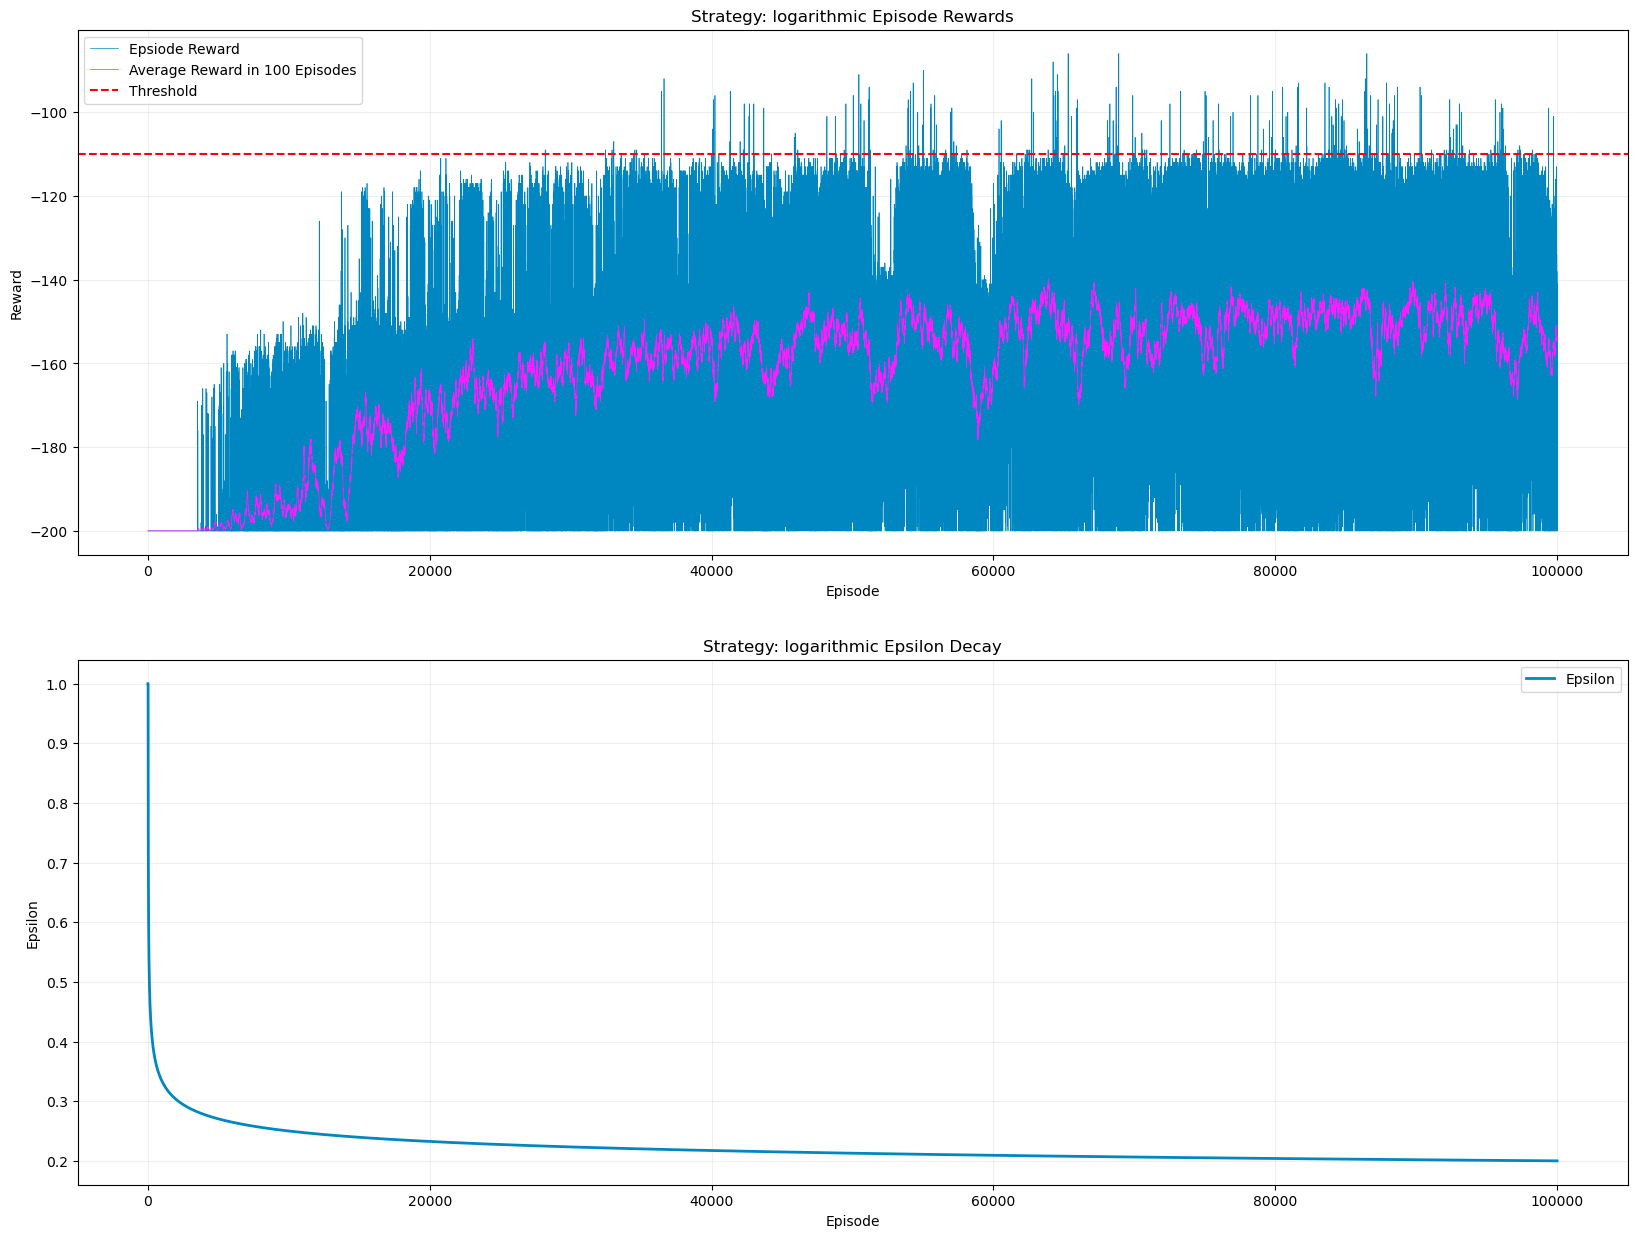

Training using exponential Strategy
threshold: -110.0
Episode 5000/100000 | Average Reward: -200.00 | Epsilon: 0.7788
Episode 10000/100000 | Average Reward: -200.00 | Epsilon: 0.6066
Episode 15000/100000 | Average Reward: -197.88 | Epsilon: 0.4724
Episode 20000/100000 | Average Reward: -187.53 | Epsilon: 0.3679
Episode 25000/100000 | Average Reward: -178.28 | Epsilon: 0.2865
Episode 30000/100000 | Average Reward: -168.05 | Epsilon: 0.2231
Episode 35000/100000 | Average Reward: -165.46 | Epsilon: 0.1738
Episode 40000/100000 | Average Reward: -152.91 | Epsilon: 0.1353
Episode 45000/100000 | Average Reward: -138.65 | Epsilon: 0.1054
Episode 50000/100000 | Average Reward: -158.93 | Epsilon: 0.0821
Episode 55000/100000 | Average Reward: -142.32 | Epsilon: 0.0639
Episode 60000/100000 | Average Reward: -145.23 | Epsilon: 0.0498
Episode 65000/100000 | Average Reward: -119.66 | Epsilon: 0.0388
Episode 70000/100000 | Average Reward: -132.27 | Epsilon: 0.0302
Episode 75000/100000 | Average Reward

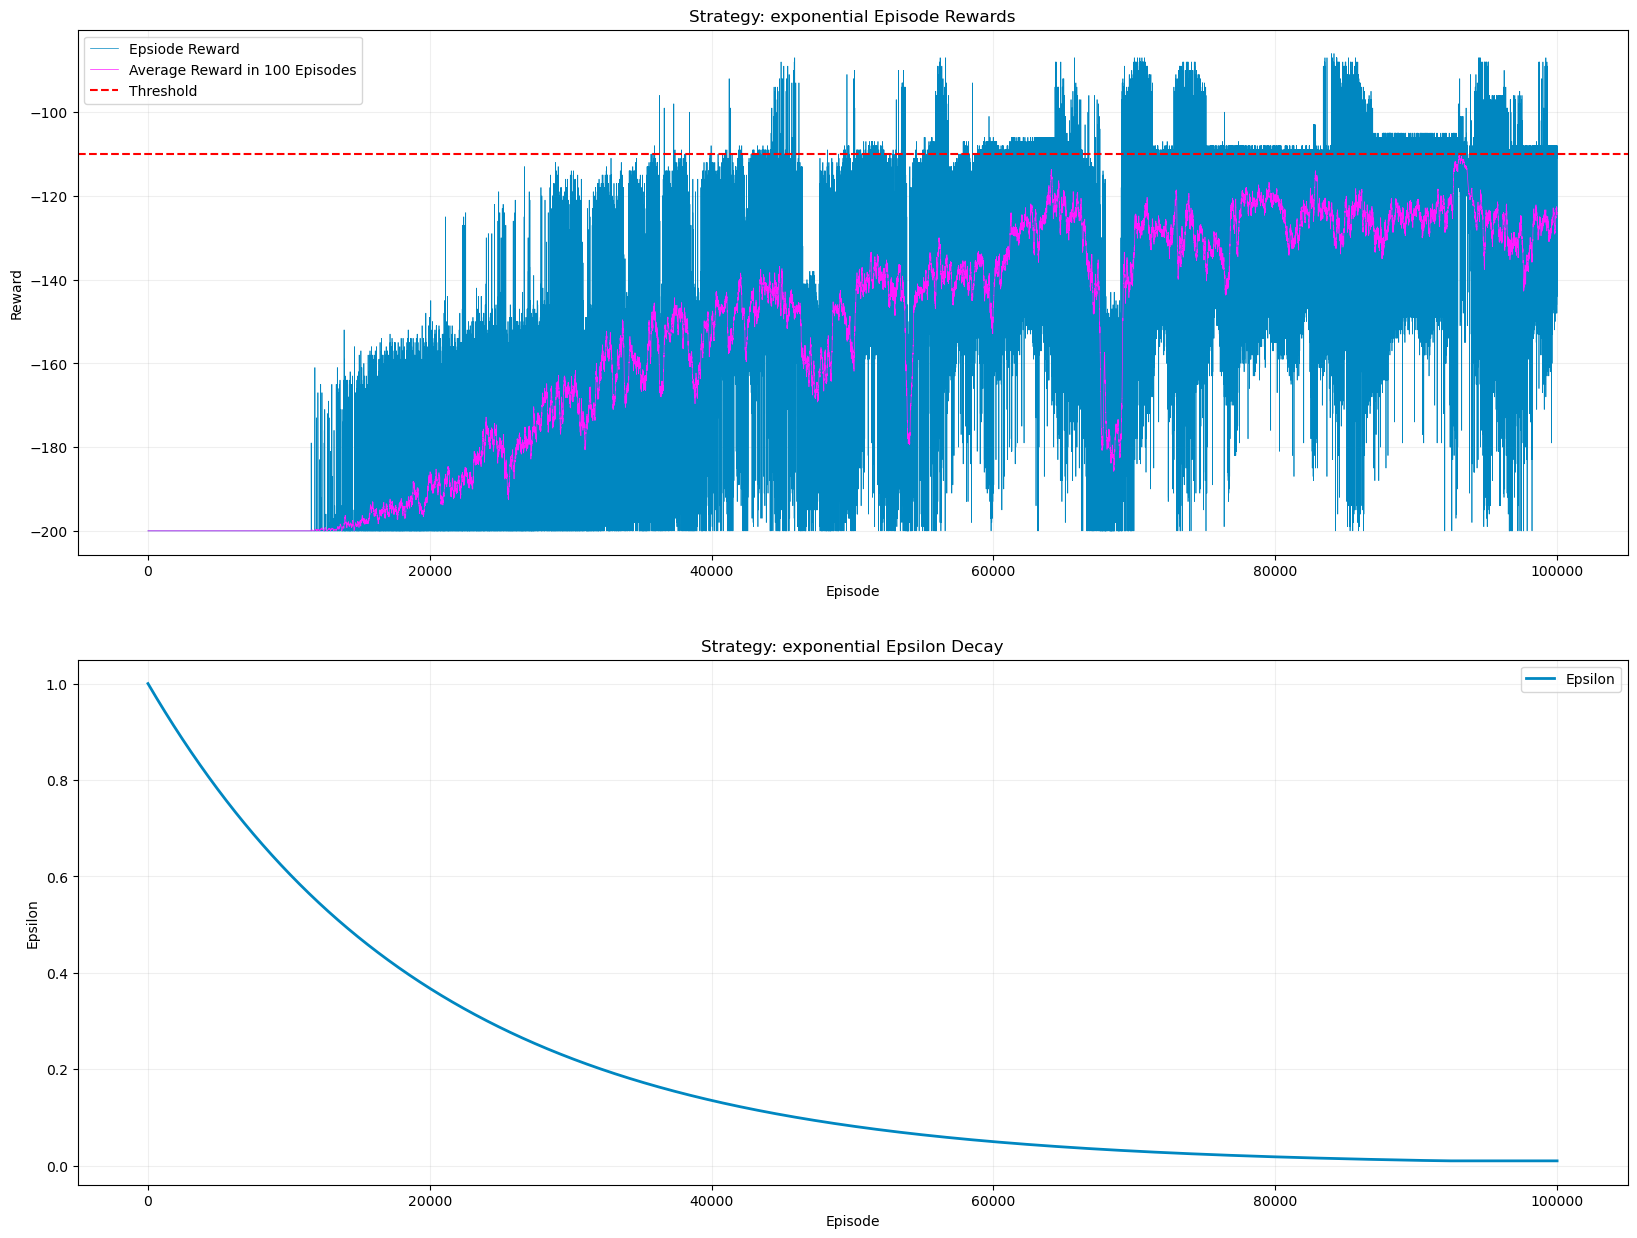

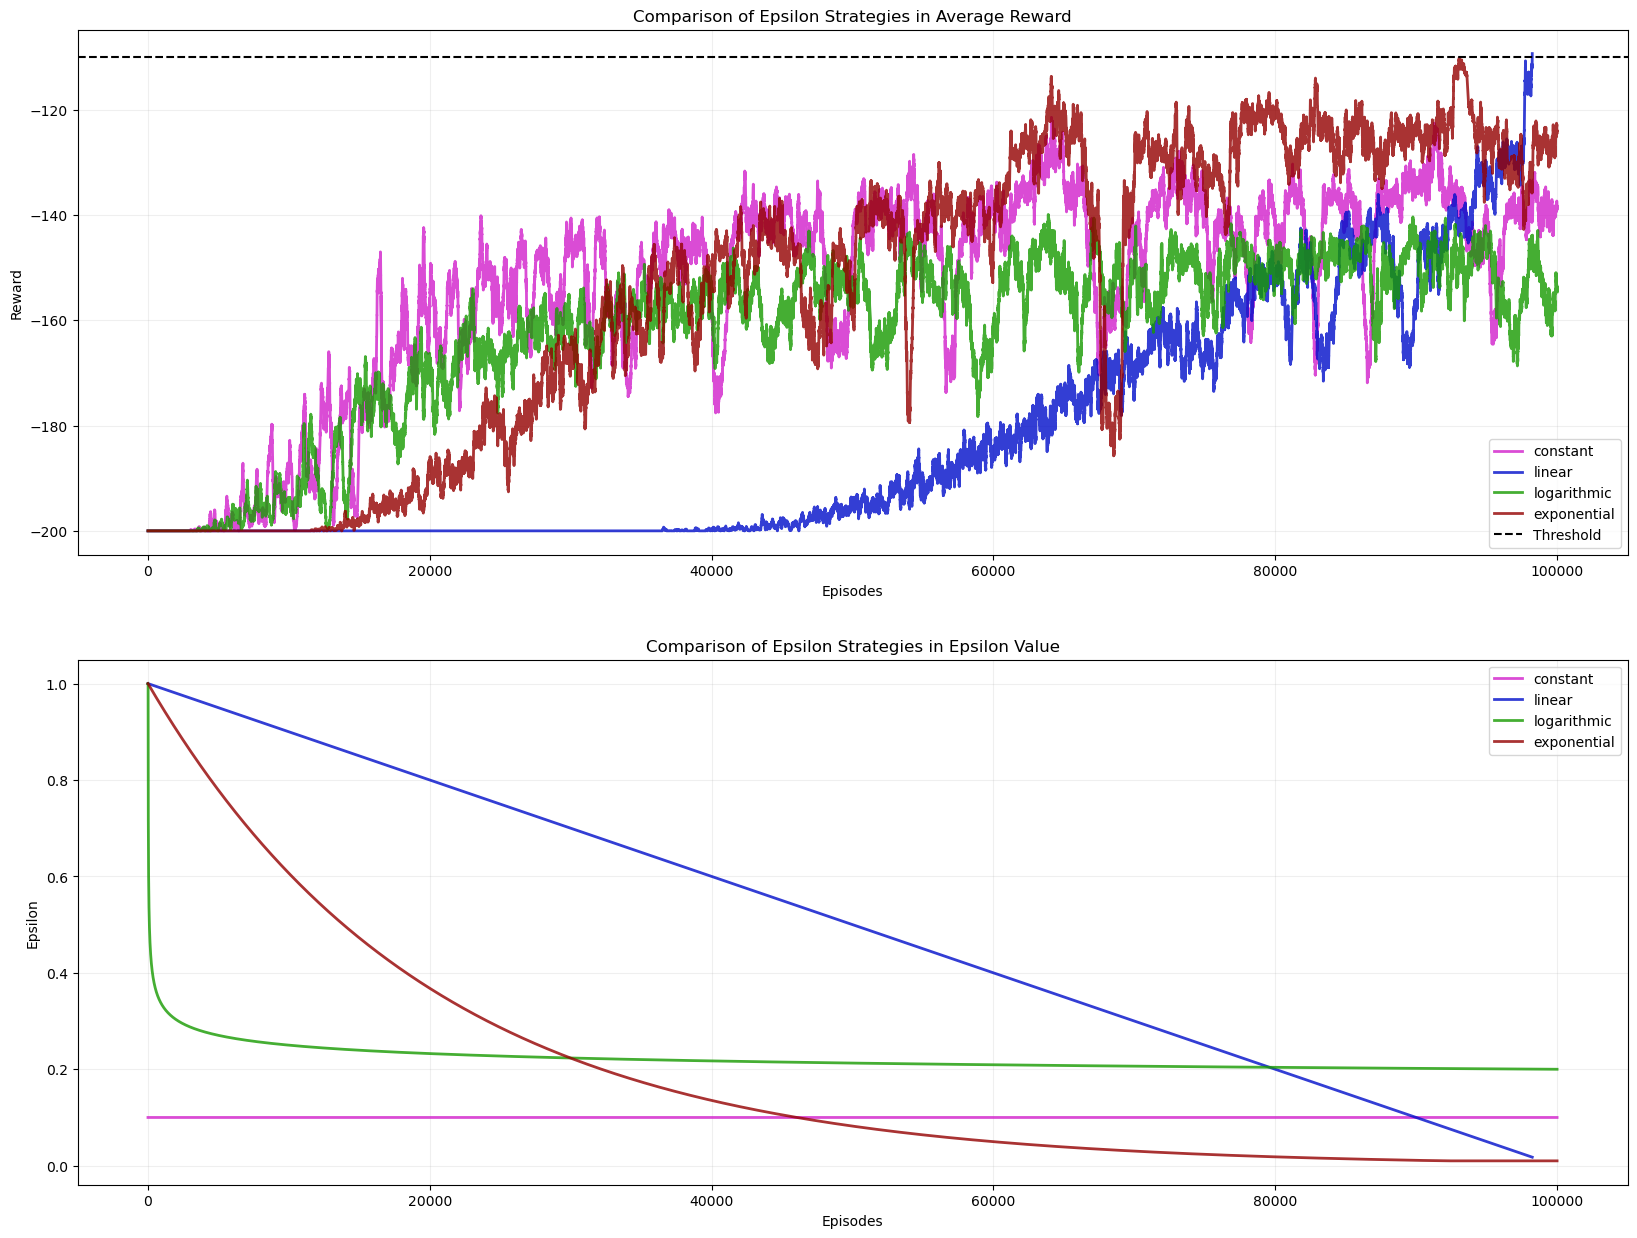

In [31]:
epsilon_results = run_epsilon_experiments(
    episodes=100000,
    buckets=(40, 40),
    seed=400
)

In [ ]:
bucket_results = run_bucket_experiments(
    episodes=100000,
    seed=400
)

### **PART 5: 3D VALUE FUNCTION VISUALIZATION**

In [ ]:
def plot_value_function(agent):
    """
    Plot the learned state-value function V(s) = max_a Q(s, a) as a 3D surface.

    TODO:
    1. Compute V(s) = max_a Q(s, a) from the agent's Q-table.
    2. Mark unvisited states (where all Q-values are zero) as NaN so they are not plotted.
    3. Create position and velocity ranges based on the agent's discretization.
    4. Create a 3D surface plot over position, velocity, and V(s).
    """
    pass

In [ ]:
plot_value_function(visual_agent)

### ‌**PART 6: REWARD SHAPING (BONUS)**

In [ ]:
class ShapedCarAgent:
    def __init__(self, env, buckets=(40, 40), alpha=0.1, gamma=0.99, episodes=5000, mode='original', seed=400):
        self.env = env
        self.buckets = buckets
        self.alpha = alpha
        self.gamma = gamma
        self.episodes = episodes
        self.mode = mode
        self.seed = seed
        self.rng = np.random.default_rng(seed)
        
        self.lower_bounds = self.env.observation_space.low
        self.upper_bounds = self.env.observation_space.high
        self.Q_table = np.zeros(self.buckets + (self.env.action_space.n,))

    def discretize_state(self, obs):
        """
        Convert continuous observation to a discrete state index.

        TODO:
        1. Scale each component of obs to [0, 1] using lower_bounds and upper_bounds.
        2. Map the scaled value to a bucket index in [0, buckets[i] - 1].
        3. Clip the index to ensure it lies within valid range.
        4. Return the discrete state as a tuple of indices.
        """

        pass

    def choose_action(self, state, epsilon):
        """
        Select an action using an epsilon-greedy policy.

        TODO:
        1. With probability epsilon, select a random action (exploration).
        2. Otherwise, select the greedy action (argmax over Q_table at this state).
        3. Return the selected action.
        """
        pass

    def get_epsilon(self, episode):
        """
        Compute epsilon for the given episode.
        TODO:
        1. Implement an epsilon schedule (e.g., logarithmic decay, linear decay, etc.).
        2. Make sure epsilon stays within [0.01, 1.0].
        """
        pass

    def train(self):
        """
        Train the shaped Q-learning agent.

        Returns:
            scores_array: list of original (environment) rewards per episode.
            success_array: list of 0/1 flags indicating whether the goal was reached.
        
        TODO:
        1. For each episode:
           - Reset the environment (optionally using a different seed per episode).
           - Discretize the initial observation.
           - Compute epsilon using get_epsilon.
        2. Run the episode loop:
           - Choose an action using epsilon-greedy.
           - Step the environment.
           - Discretize the next observation.
           - Compute a learning reward that depends on `mode`
           - Accumulate the original environment reward for logging.
        3. Log:
           - Append the total original reward to scores_array.
           - Append 1 to success_array if the goal was reached, else 0.
        """
        scores_array = []
        success_array = []
        
        pass

In [ ]:
"""
TODO:
Run reward shaping experiments and compare different modes:

1. Define the list of modes:
   ['original', 'hacked', 'shaping1', 'shaping2', 'shaping3']

2. For each mode:
   - Create a new MountainCar-v0 environment.
   - Initialize a ShapedCarAgent with the given mode.
   - Train the agent.
   - Store:
        * Episode rewards (original environment reward)
        * Success flags (0/1)
   - Close the environment.

3. Plot:
   - Smoothed learning curves (moving average of rewards).
   - Smoothed success rates (moving average of success flags).
"""

modes = ['original', 'hacked', 'shaping1', 'shaping2', 'shaping3']
results = {}